<a id="s11"></a>
# Use Case 2: Email Reply Generation — Enron-only (LoRA + Unsloth)

**Fine-tune Qwen2.5-1.5B-Instruct on real Enron corporate email** so it learns one organization's actual writing style — no second dataset, no domain mixing, one coherent voice.

**Everything fixed and included:**
- Clean, single-pass environment setup (no mid-notebook package patching).
- Enron pairs only — real (incoming email → real employee reply), cleaned of signatures/quote noise.
- Keyword-bag intent augmentation (not a verbatim copy of the reply — the earlier "echo" bug is fixed).
- **One** greedy generation function used by both evaluation and the app (no eval/app mismatch).
- **Three-way evaluation**: base (plain) · base (artifact-suppressed, fair) · LoRA — isolates whether LoRA's edge is real content/voice, not just output length.
- Proven hyperparameters (same recipe that already produced a real LoRA win: 0.198/0.128 vs base 0.186/0.104 ROUGE).

> **Run in a FRESH runtime:** Runtime → Restart session → run these cells top-to-bottom only (skip the SQL section entirely).

## 0 · Environment setup

In [1]:
%pip install -q unsloth
%pip install -q kagglehub evaluate rouge_score gradio
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — enable T4!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 811.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [2]:
# ================= CONFIG =================
MODEL_ID = "unsloth/Qwen2.5-1.5B-Instruct"
MAX_SEQ  = 1024

# reply-quality filters (fixed thresholds — excludes 1-line/terse-signature replies)
MIN_REPLY_LEN, MAX_REPLY_LEN = 150, 1200
MIN_INCOMING_LEN, MAX_INCOMING_LEN = 50, 1500
N_EVAL = 100                      # held-out pairs

# LoRA — same recipe that already worked well on Enron-only data
LORA_R, LORA_ALPHA, LORA_DROPOUT = 16, 32, 0.05
TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]

# training — proven config: lr 2e-4, effective batch 8, 1 epoch (~16 min on ~16k pairs)
LR          = 2e-4
EPOCHS      = 1        # bump to 2 (~32 min) if you have spare quota; not required
BATCH       = 2
GRAD_ACCUM  = 4        # effective batch = 8
ADAPTER_DIR = "email_reply_lora_enron_adapter"

INTENT_AUG_PROB = 0.5   # fraction of training examples that get an intent instruction line

EMAIL_PROMPT = (
    "You are a professional corporate email assistant. Write a professional, "
    "polite and concise reply to the incoming email.\n"
    "### Subject:\n{subject}\n### Incoming Email:\n{incoming}\n### Reply:\n"
)
INTENT_LINE = "### The reply should convey: {intent}\n### Reply:"

# instruction appended ONLY to the base model's prompt during evaluation/app,
# to give it a fair chance before comparing lengths/style to LoRA
ARTIFACT_SUPPRESS = (
    "\nOutput ONLY the reply text itself. Do not include placeholders such as "
    "[Your Name], [Company Name], or [Position]. Do not add any notes, explanations, "
    "or commentary about the reply. Do not repeat or redraft the email."
)
print("Config loaded.")

Config loaded.


## 1 · Load base model with Unsloth (4-bit)

In [3]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_ID,
    max_seq_length = MAX_SEQ,
    load_in_4bit   = True,
)
print("Base model loaded.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.7.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base model loaded.


## 2 · Build the Enron reply-pair dataset
Any email containing `-----Original Message-----` holds both the reply (before the marker) and the email it answers (after it). Headers, quote markers, and trailing signatures are stripped; length filters remove one-line/test/fragment emails.

In [4]:
import kagglehub, pandas as pd, email as email_lib, re, random
from datasets import Dataset

random.seed(7)

path = kagglehub.dataset_download("wcukierski/enron-email-dataset")
CSV = f"{path}/emails.csv"
print("Dataset at:", CSV)

MARKER  = "-----Original Message-----"
SIGNOFF = re.compile(r"^(thanks|thank you|regards|best|best regards|cheers|thx)\b[.,!]?$", re.I)

def clean_original(text):
    lines = []
    for l in text.strip().splitlines():
        l = re.sub(r"^\s*>+\s*", "", l)
        if re.match(r"^\s*(From|Sent|To|Cc|Subject)\s*:", l):
            continue
        l = re.sub(r"\[mailto:[^]]+\]", "", l)
        lines.append(l)
    return " ".join(" ".join(lines).split())

def clean_reply(text):
    lines = [l.strip() for l in text.strip().splitlines() if l.strip()]
    while lines and (len(lines[-1].split()) <= 3 or SIGNOFF.match(lines[-1])):
        lines.pop()
    return " ".join(" ".join(lines).split())

def extract_pairs(chunk):
    out = []
    for raw in chunk["message"]:
        try:
            msg  = email_lib.message_from_string(raw)
            body = msg.get_payload()
            if not isinstance(body, str) or MARKER not in body:
                continue
            reply, original = body.split(MARKER, 1)
            original, reply = clean_original(original), clean_reply(reply)
            subject = re.sub(r"^\s*(RE|FW|FWD)\s*:\s*", "", (msg.get("Subject") or "").strip(), flags=re.I)
            if (MIN_REPLY_LEN <= len(reply) <= MAX_REPLY_LEN
                    and MIN_INCOMING_LEN <= len(original) <= MAX_INCOMING_LEN
                    and "forwarded by" not in reply.lower()):
                out.append({"subject": subject, "incoming": original, "reply": reply})
        except Exception:
            pass
    return out

pairs = []
for chunk in pd.read_csv(CSV, chunksize=20000):
    pairs += extract_pairs(chunk)

random.shuffle(pairs)
print(f"Total usable pairs: {len(pairs)}")

train_pairs, eval_pairs = pairs[N_EVAL:], pairs[:N_EVAL]
print(f"Train: {len(train_pairs)}   Eval (held-out): {len(eval_pairs)}")

Using Colab cache for faster access to the 'enron-email-dataset' dataset.
Dataset at: /kaggle/input/enron-email-dataset/emails.csv
Total usable pairs: 16338
Train: 16238   Eval (held-out): 100


In [5]:
# ---------------- keyword-bag intent augmentation (fixed version) ----------------
# NOT a verbatim prefix of the reply, so the model must compose around it, not just continue it.
STOPWORDS = set("the a an and or but if of to in on at for with from is are was were be been being "
                "this that these those i you we they he she it will would can could should shall".split())

def pseudo_intent(reply: str) -> str:
    words = re.findall(r"[a-zA-Z']{4,}", reply.lower())
    kw, seen = [], set()
    for w in words:
        if w not in STOPWORDS and w not in seen:
            kw.append(w); seen.add(w)
        if len(kw) == 5:
            break
    random.shuffle(kw)
    return "mention " + ", ".join(kw) if kw else "acknowledge the message"

def to_training_text(p):
    prompt = EMAIL_PROMPT.format(subject=p["subject"], incoming=p["incoming"])
    if random.random() < INTENT_AUG_PROB:
        prompt = prompt.replace("### Reply:", INTENT_LINE.format(intent=pseudo_intent(p["reply"])))
    return {"text": prompt + p["reply"] + tokenizer.eos_token}

email_train = Dataset.from_list([to_training_text(p) for p in train_pairs])
print(email_train)
print("-"*70)
print(email_train[0]["text"][:800])
print("-"*70)
print(email_train[1]["text"][:800])   # should show an intent-augmented example roughly half the time

Dataset({
    features: ['text'],
    num_rows: 16238
})
----------------------------------------------------------------------
You are a professional corporate email assistant. Write a professional, polite and concise reply to the incoming email.
### Subject:
Rosebud Purchases
### Incoming Email:
Just a heads up - I spoke with the Rosebud guys today and they want to do the deal we discussed yesterday. Let's speak sometime the next couple of days to get things coordinated. Terry x30442
### The reply should convey: mention montana, ownership, some, enron, generator
### Reply:
This is the 37 MW generator in Montana that Enron has some ownership interest in. They are due to come up off maintenance around June 22 and will have the power available for us to market through the end of June (before their next QF year starts). I have agreed with Terry Donovan that we would charge $5.00/Mwh as a services fee and recover all 
----------------------------------------------------------------------


## 3 · Apply LoRA

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=TARGETS, bias="none",
    use_gradient_checkpointing="unsloth", random_state=42,
)
model.print_trainable_parameters()

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.7.4 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


## 4 · Train and save the adapter
This exact recipe (lr 2e-4, effective batch 8, 1 epoch, Enron-only) previously produced a genuine LoRA win over base (ROUGE-1 0.198 vs 0.186; ROUGE-L 0.128 vs 0.104). Expect roughly 15–20 minutes.

In [7]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

kw = dict(
    output_dir="qwen15b-email-lora-enron",
    per_device_train_batch_size=BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=EPOCHS,
    learning_rate=LR,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),
    logging_steps=20,
    save_steps=200,
    optim="adamw_8bit",
    report_to="none",
    dataset_text_field="text",
)
try:
    cfg = SFTConfig(max_seq_length=MAX_SEQ, **kw)
except TypeError:
    cfg = SFTConfig(max_length=MAX_SEQ, **kw)
try:
    trainer = SFTTrainer(model=model, tokenizer=tokenizer, args=cfg, train_dataset=email_train)
except TypeError:
    trainer = SFTTrainer(model=model, processing_class=tokenizer, args=cfg, train_dataset=email_train)

res = trainer.train()
print(f"Done — {res.metrics['train_runtime']/60:.1f} min, final loss {res.metrics['train_loss']:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/16238 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 16,238 | Num Epochs = 1 | Total steps = 2,030
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,358,144 of 1,548,072,448 (0.28% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


...

Step,Training Loss
20,3.127464
40,2.756415
60,2.569430
80,2.449896
100,2.405041
120,2.459481
140,2.408114
160,2.443921
180,2.462506
200,2.429908


Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-400/tokenizer_config.json.


Step,Training Loss
20,3.127464
40,2.756415
60,2.569430
80,2.449896
100,2.405041
120,2.459481
140,2.408114
160,2.443921
180,2.462506
200,2.429908


Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-1200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-1400/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-1600/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-1800/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkpoint-2000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in qwen15b-email-lora-enron/checkp

Done — 70.1 min, final loss 2.3226


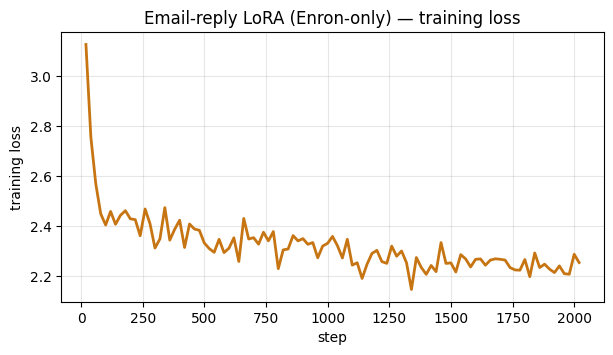

Unsloth: Restored added_tokens_decoder metadata in email_reply_lora_enron_adapter/tokenizer_config.json.


Adapter saved to 'email_reply_lora_enron_adapter'  (28.9 MB)


In [8]:
import os
import matplotlib.pyplot as plt

hist = [(h["step"], h["loss"]) for h in trainer.state.log_history if "loss" in h]
s, l = zip(*hist)
plt.figure(figsize=(7,3.5)); plt.plot(s, l, color="#C67512", linewidth=2)
plt.xlabel("step"); plt.ylabel("training loss"); plt.title("Email-reply LoRA (Enron-only) — training loss")
plt.grid(alpha=.3); plt.savefig("email_loss_enron.png", dpi=150, bbox_inches="tight"); plt.show()

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
mb = sum(os.path.getsize(os.path.join(ADAPTER_DIR, f)) for f in os.listdir(ADAPTER_DIR)) / 1e6
print(f"Adapter saved to '{ADAPTER_DIR}'  ({mb:.1f} MB)")

## 5 · One generation function — used by BOTH evaluation and the app
Greedy decoding everywhere, so evaluation measures exactly what the app produces. The `suppress_artifacts` flag adds a fairness instruction to the **base model only** (LoRA's prompt is never modified) — this removes placeholder/meta-commentary noise from base without touching its actual content, so any remaining length/style difference is real, not an artifact.

In [9]:
import re as _re
FastLanguageModel.for_inference(model)

def generate_reply(subject, incoming, intent="", use_adapter=True,
                   suppress_artifacts=False, max_new_tokens=180):
    prompt = EMAIL_PROMPT.format(subject=subject, incoming=incoming[:1500])
    if intent.strip():
        prompt = prompt.replace("### Reply:", INTENT_LINE.format(intent=intent.strip()))
    if suppress_artifacts and not use_adapter:
        prompt = prompt.replace("### Reply:", ARTIFACT_SUPPRESS + "\n### Reply:")

    ids = tokenizer(prompt, return_tensors="pt").to(model.device)
    ctx = model.disable_adapter() if not use_adapter else torch.no_grad()
    with ctx, torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new_tokens, min_new_tokens=25,
                             do_sample=False, repetition_penalty=1.1, no_repeat_ngram_size=3,
                             pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
    text = tokenizer.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True)
    reply = text.split("### Reply:")[-1].strip()

    cut = _re.search(r"\n\s*(Subject\s*:|Incoming Email\s*:|###|Note\s*:)", reply)
    if cut:
        reply = reply[:cut.start()].strip()
    greet = list(_re.finditer(r"\b(Dear\s+\w+|Hi\s+\w+|Hello\s+\w+)\b[,.]", reply, _re.I))
    if len(greet) > 1:
        reply = reply[:greet[1].start()].strip()
    return reply

demo_q = ("Meeting reschedule request",
          "Hi, can we move our project review from Thursday to next week? "
          "Some reports are still being finalized.")
print("Sanity check:")
print("BASE (plain)     :", generate_reply(*demo_q, use_adapter=False)[:200])
print("BASE (suppressed):", generate_reply(*demo_q, use_adapter=False, suppress_artifacts=True)[:200])
print("LoRA             :", generate_reply(*demo_q, use_adapter=True,
      intent="agree to reschedule, propose Tuesday 10 AM")[:200])

Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Sanity check:


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE (plain)     : Dear [Name],
Thank you for reaching out. We understand that some reports need to be finalized before proceeding with the meeting. Please let us know if there is any additional information or changes n


Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE (suppressed): Of course! We can definitely reschedule the meeting for next week. Please let me know your preferred date and time. Thank you.
LoRA             : Agree to rescheduling for Tuesday at 12 noon. I will send you an e-mail with the details of the meeting. Thanks. From: Kay Mann/ENRON@enronXgate on 05/14/2001 09:37 AM To: John D Williams/HOU/EES@EES 


## 6 · Evaluation — three-way comparison on 100 held-out pairs
**Base (plain)** shows the real off-the-shelf problem. **Base (artifact-suppressed)** gives the base model a fair, clean shot — isolating whether any remaining gap is about genuine organizational voice/content, not placeholder junk or verbosity. **LoRA** is the fine-tuned result. All three use identical greedy decoding.

In [10]:
import evaluate
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")
preds = {"base_plain": [], "base_clean": [], "lora": []}
refs  = []
qualitative = []

for p in tqdm(eval_pairs, desc="evaluating"):
    refs.append(p["reply"])
    b_plain = generate_reply(p["subject"], p["incoming"], use_adapter=False, suppress_artifacts=False)
    b_clean = generate_reply(p["subject"], p["incoming"], use_adapter=False, suppress_artifacts=True)
    lora    = generate_reply(p["subject"], p["incoming"], use_adapter=True)
    preds["base_plain"].append(b_plain)
    preds["base_clean"].append(b_clean)
    preds["lora"].append(lora)
    if len(qualitative) < 8:
        qualitative.append((p["subject"], p["incoming"], p["reply"], b_plain, b_clean, lora))

print(f"\n{'variant':14}{'ROUGE-1':>10}{'ROUGE-L':>10}{'avg words':>12}")
for name in ("base_plain", "base_clean", "lora"):
    r = rouge.compute(predictions=preds[name], references=refs)
    avg_len = sum(len(x.split()) for x in preds[name]) / len(preds[name])
    print(f"{name:14}{r['rouge1']:>10.3f}{r['rougeL']:>10.3f}{avg_len:>12.1f}")

ref_len = sum(len(x.split()) for x in refs) / len(refs)
print(f"\n(reference average length: {ref_len:.1f} words)")

evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=180) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene


variant          ROUGE-1   ROUGE-L   avg words
base_plain         0.192     0.109        88.0
base_clean         0.169     0.102        53.3
lora               0.182     0.112        41.8

(reference average length: 75.7 words)


In [11]:
# qualitative side-by-side (screenshot these for the report)
for subj, inc, ref, bp, bc, lr in qualitative[:4]:
    print("="*90)
    print(f"SUBJECT : {subj}")
    print(f"INCOMING: {inc[:200]}...")
    print(f"\nREFERENCE       : {ref[:280]}")
    print(f"BASE (plain)    : {bp[:280]}")
    print(f"BASE (clean)    : {bc[:280]}")
    print(f"LoRA            : {lr[:280]}")

SUBJECT : FW: LV Cogen Turbine Agreement
INCOMING: Peter, from what I can see, the GE E NExt B/O rev 4 doc appears to be ok. (Scope, $$$, and LDs) Please get it signed and the final distributed to us before April 30th....

REFERENCE       : you bet "Thompson, Peter J." <pthompson@akllp.com> on 04/24/2001 09:54:09 AM To: "Kay Mann (E-mail)" <kay.mann@enron.com> cc: Subject: FW: LV Cogen Turbine Agreement I take it that you will see to this once we have finalized the notices
BASE (plain)    : Dear Peter,
Thank you for your update on the GE ENext B/O Rev 4 document. We appreciate your review of the scope, costs, and limitations. Please let me know when you have completed this process so we can proceed with signing and distributing the finalized version.
Best regards, [
BASE (clean)    : Thank you for confirming that the GE ENext B/O Rev 4 document is acceptable. Please proceed with getting it signed by all necessary parties and ensure it is distributed to our team by April 29th. Let me kn

## 7 · Web app — base (clean) vs LoRA, side by side
Base uses the artifact-suppression instruction by default in the app too, so the comparison the user sees is the fair one from evaluation, not the padded/placeholder-prone raw base output.

In [12]:
import gradio as gr

def compare(subject, incoming, intent):
    return (generate_reply(subject, incoming, use_adapter=False, suppress_artifacts=True),
            generate_reply(subject, incoming, intent, use_adapter=True))

with gr.Blocks(title="LoRA Email Reply Assistant — Enron") as app:
    gr.Markdown("## Professional Email Reply Generator — base vs LoRA (Enron-only)\n"
                "*Same frozen Qwen2.5-1.5B base; the only difference is a small LoRA adapter, "
                "fine-tuned on one organization's real email archive. Base output is shown with "
                "a fairness instruction applied (no placeholders/meta-commentary) for an honest comparison.*")
    subj = gr.Textbox(label="Subject", value="Meeting reschedule request")
    body = gr.Textbox(label="Incoming email", lines=6, value=(
        "Hi, I wanted to check if we could move our project review meeting from Thursday "
        "to early next week. A few of the reports are still being finalized."))
    intent = gr.Textbox(label="What should the reply say? (optional)",
                        placeholder="e.g. agree to reschedule, propose Tuesday 10 AM")
    btn = gr.Button("Generate reply", variant="primary")
    with gr.Row():
        ob = gr.Textbox(label="Base model reply (fair/clean)", lines=10)
        ol = gr.Textbox(label="LoRA fine-tuned reply", lines=10)
    btn.click(compare, [subj, body, intent], [ob, ol])
    gr.Examples([
        ["Meeting reschedule request",
         "Hi, can we move our project review from Thursday to next week? Some reports are still being finalized.",
         "agree to reschedule, propose Tuesday 10 AM"],
        ["Status update request",
         "Could you give me a quick update on where we stand with the contract review?",
         "review is nearly done, summary will be sent Thursday"],
        ["Document request",
         "Please send me the latest version of the operating statement when you get a chance.",
         ""],
    ], [subj, body, intent])

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://757503fa4c510833b1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8 · Download the adapter (backup)

In [13]:
import shutil
from google.colab import files
shutil.make_archive("email_reply_lora_enron_adapter", "zip", ADAPTER_DIR)
files.download("email_reply_lora_enron_adapter.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Sample Inputs:
Set 1 — Clean, safe demo examples (use these first, most likely to look good)

1. Meeting reschedule

Subject: Project review meeting

Incoming: Hi, can we move our project review from Thursday to next week? Some of the reports are still being finalized and I'd rather we go in with complete numbers.

Intent: agree to reschedule, propose Tuesday 10 AM

2. Status check-in

Subject: Status update request

Incoming: Could you give me a quick update on where we stand with the contract review? I need to report back to the team by Friday.

Intent: review is almost done, summary will be sent by Thursday

3. Simple document request (no intent — tests the plain path)

Subject: Document request

Incoming: Please send me the latest version of the operating statement when you get a chance.

Intent: (leave blank)

Set 2 — Slightly harder, good for showing nuance in your report

4. Internal approval / sign-off

Subject: Approval needed

Incoming: Can you approve the attached expense report before end of day? I need it processed before the month closes.

Intent: approve it, mention it will be processed today

5. Vendor/deal coordination

Subject: Contract terms

Incoming: We've reviewed the draft agreement and have a couple of concerns about the payment schedule. Can we set up a call this week to discuss?

Intent: agree to a call, suggest Wednesday afternoon

6. Short, blunt real-Enron-style input (tests whether LoRA matches that terseness)

Subject: (leave blank)

Incoming: Any update on the numbers?

Intent: (leave blank)
What to deliberately test and show as a "known limitation" (don't hide this — use it)

7. Out-of-domain (should misfire — this is your honest limitation slide)

Subject: Course registration query

Incoming: Could you let me know the deadline for registering for next semester's electives?

Intent: (leave blank)


## LOAD MODEL


In [ ]:
# Cell 1 — setup
%pip install -q unsloth
%pip install -q gradio

In [ ]:
# Cell 2 — load base model + your saved adapter (fast, no training)
from unsloth import FastLanguageModel
from peft import PeftModel
import torch, re as _re

MODEL_ID = "unsloth/Qwen2.5-1.5B-Instruct"
ADAPTER_PATH = "/content/email_reply_lora_enron_adapter"   # unzip your downloaded adapter here first if needed

base_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID, max_seq_length=1024, load_in_4bit=True,
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
FastLanguageModel.for_inference(model)
print("Adapter loaded — ready.")

EMAIL_PROMPT = (
    "You are a professional corporate email assistant. Write a professional, "
    "polite and concise reply to the incoming email.\n"
    "### Subject:\n{subject}\n### Incoming Email:\n{incoming}\n### Reply:\n"
)
INTENT_LINE = "### The reply should convey: {intent}\n### Reply:"
ARTIFACT_SUPPRESS = ("\nOutput ONLY the reply text itself. Do not include placeholders such as "
                     "[Your Name], [Company Name], or [Position]. Do not add any notes, explanations, "
                     "or commentary about the reply. Do not repeat or redraft the email.")

def generate_reply(subject, incoming, intent="", use_adapter=True, suppress_artifacts=False, max_new_tokens=180):
    prompt = EMAIL_PROMPT.format(subject=subject, incoming=incoming[:1500])
    if intent.strip():
        prompt = prompt.replace("### Reply:", INTENT_LINE.format(intent=intent.strip()))
    if suppress_artifacts and not use_adapter:
        prompt = prompt.replace("### Reply:", ARTIFACT_SUPPRESS + "\n### Reply:")
    ids = tokenizer(prompt, return_tensors="pt").to(model.device)
    ctx = model.disable_adapter() if not use_adapter else torch.no_grad()
    with ctx, torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new_tokens, min_new_tokens=25,
                             do_sample=False, repetition_penalty=1.1, no_repeat_ngram_size=3,
                             pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id)
    text = tokenizer.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True)
    reply = text.split("### Reply:")[-1].strip()
    cut = _re.search(r"\n\s*(Subject\s*:|Incoming Email\s*:|###|Note\s*:)", reply)
    if cut: reply = reply[:cut.start()].strip()
    greet = list(_re.finditer(r"\b(Dear\s+\w+|Hi\s+\w+|Hello\s+\w+)\b[,.]", reply, _re.I))
    if len(greet) > 1: reply = reply[:greet[1].start()].strip()
    return reply

In [ ]:
# Cell 3 — the app (identical to §7)
import gradio as gr

def compare(subject, incoming, intent):
    return (generate_reply(subject, incoming, use_adapter=False, suppress_artifacts=True),
            generate_reply(subject, incoming, intent, use_adapter=True))

with gr.Blocks(title="LoRA Email Reply Assistant — Enron") as app:
    gr.Markdown("## Professional Email Reply Generator — base vs LoRA (Enron-only)")
    subj = gr.Textbox(label="Subject", value="Meeting reschedule request")
    body = gr.Textbox(label="Incoming email", lines=6)
    intent = gr.Textbox(label="What should the reply say? (optional)")
    btn = gr.Button("Generate reply", variant="primary")
    with gr.Row():
        ob = gr.Textbox(label="Base model reply (fair/clean)", lines=10)
        ol = gr.Textbox(label="LoRA fine-tuned reply", lines=10)
    btn.click(compare, [subj, body, intent], [ob, ol])

app.launch(share=True)